# Task 2 — Exploratory Data Analysis (EDA)

## Netflix Dataset

### Objective

The objective of this task is to explore the Netflix dataset and uncover meaningful trends, patterns, and insights.

### Workflow

1. Analyze dataset structure and statistics.
2. Study content distribution by type.
3. Identify top countries and categories.
4. Create visualizations for key metrics.
5. Summarize key findings.

### Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/netflix_cleaned.csv")

In [4]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90,min
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1,Season
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,1,Season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,125,min


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8790, 14)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         8790 non-null   object
 1   type            8790 non-null   object
 2   title           8790 non-null   object
 3   director        6202 non-null   object
 4   country         8503 non-null   object
 5   date_added      8790 non-null   object
 6   release_year    8790 non-null   int64 
 7   rating          8790 non-null   object
 8   duration        8790 non-null   object
 9   listed_in       8790 non-null   object
 10  added_year      8790 non-null   int64 
 11  added_month     8790 non-null   int64 
 12  duration_value  8790 non-null   int64 
 13  duration_unit   8790 non-null   object
dtypes: int64(4), object(10)
memory usage: 961.5+ KB


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8786,9-Feb,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6202,4527,Rajiv Chilaka,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8503,85,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,2020-01-01,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790.0,NaN,NaN,NaN,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8790,14,TV-MA,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 8790
Number of Columns: 14


In [9]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- show_id
- type
- title
- director
- country
- date_added
- release_year
- rating
- duration
- listed_in
- added_year
- added_month
- duration_value
- duration_unit


## 1. Dataset Structure and Statistical Overview

The cleaned Netflix dataset contains 8,790 records and 14 features.

The dataset includes information about content type, title, director, country, date added, release year, rating, duration, and categories.

Statistical and structural analysis was performed using Pandas to understand the dataset before conducting further exploratory analysis.

In [10]:
type_counts = df["type"].value_counts()

type_counts

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [11]:
type_percentage = df["type"].value_counts(normalize=True) * 100

type_percentage.round(2)

type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64

In [12]:
content_distribution = pd.DataFrame({
    "Count": type_counts,
    "Percentage": type_percentage.round(2)
})

content_distribution

,Count,Percentage
type,,
Movie,6126,69.69
TV Show,2664,30.31


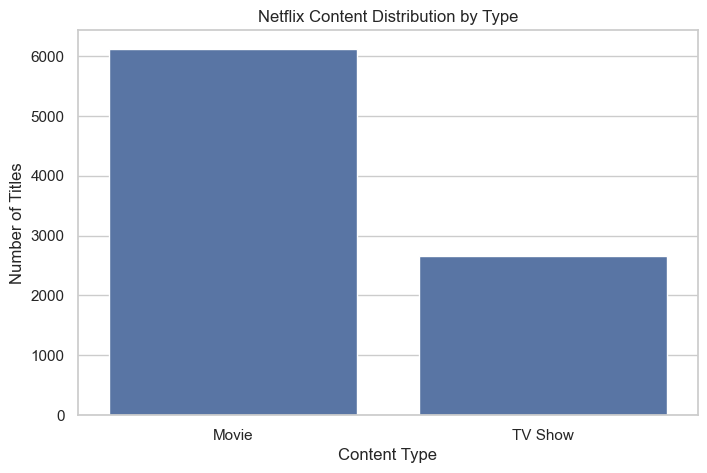

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Netflix Content Distribution by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.savefig("../outputs/Netflix_Content_Distribution_by_Type.png", dpi=300, bbox_inches="tight")

plt.show()

### Content Type Distribution

The distribution of Netflix content was analyzed to compare the number of Movies and TV Shows available in the dataset.

The visualization clearly shows the relative proportion of each content type.

In [14]:
country_data = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

country_counts = country_data.value_counts()

country_counts.head(10)

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Name: count, dtype: int64

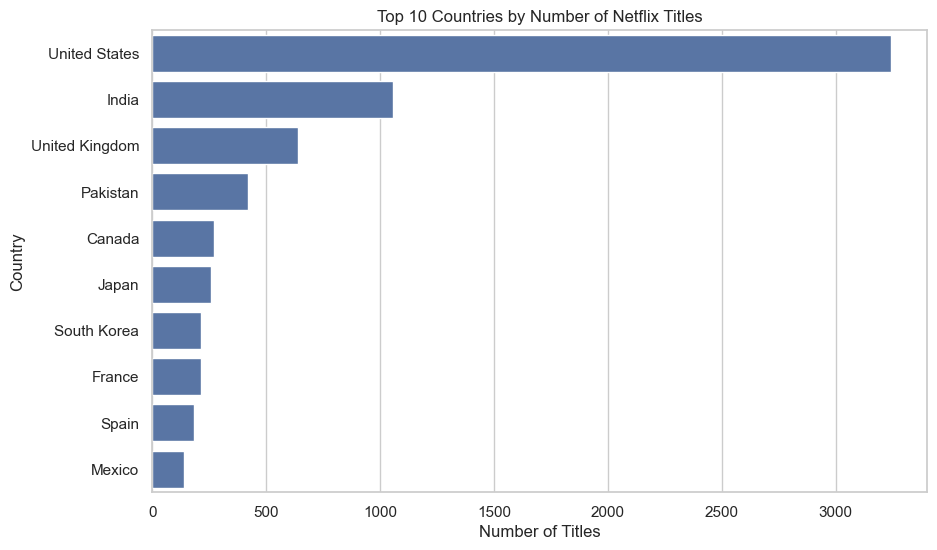

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.head(10).values,
    y=country_counts.head(10).index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.savefig("../outputs/Top_10_Countries_by_Number_of_Netflix_Titles.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
category_data = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

category_counts = category_data.value_counts()

category_counts.head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

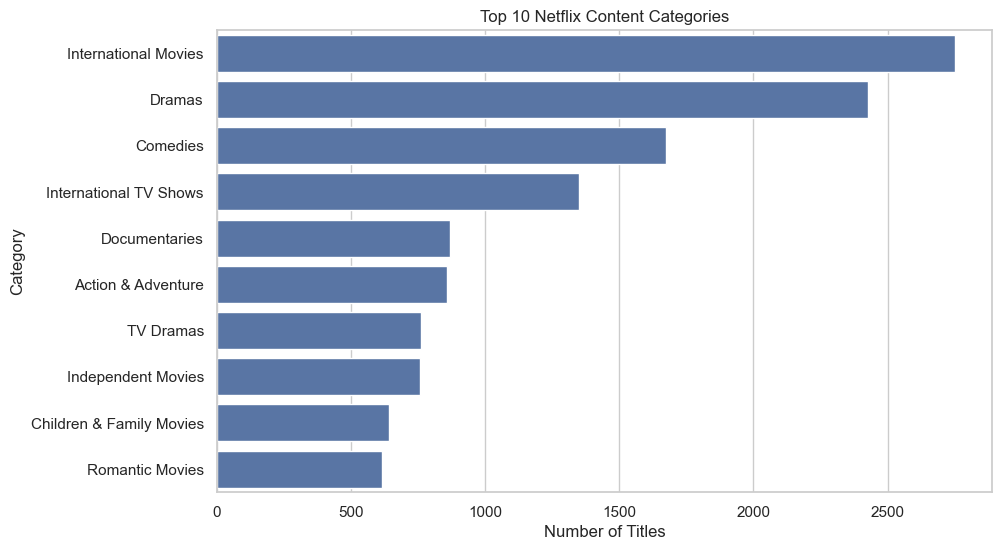

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_counts.head(10).values,
    y=category_counts.head(10).index
)

plt.title("Top 10 Netflix Content Categories")
plt.xlabel("Number of Titles")
plt.ylabel("Category")

plt.savefig("../outputs/Top_10_Netflix_Content_Categories.png", dpi=300, bbox_inches="tight")

plt.show()

In [18]:
rating_counts = df["rating"].value_counts()

rating_counts.head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

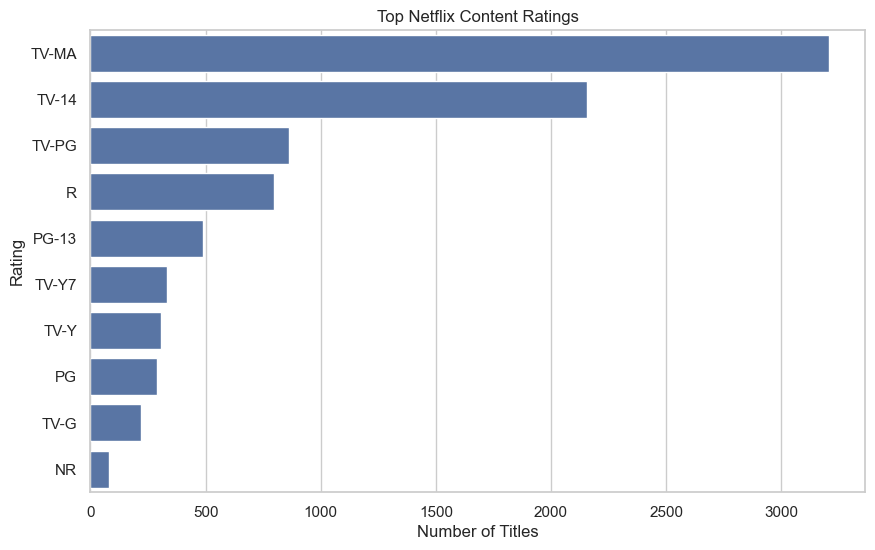

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().head(10).index
)

plt.title("Top Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.savefig("../outputs/Top_Netflix_Content_Ratings.png", dpi=300, bbox_inches="tight")

plt.show()

In [20]:
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(20)

release_year
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     286
2014     352
2015     555
2016     901
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

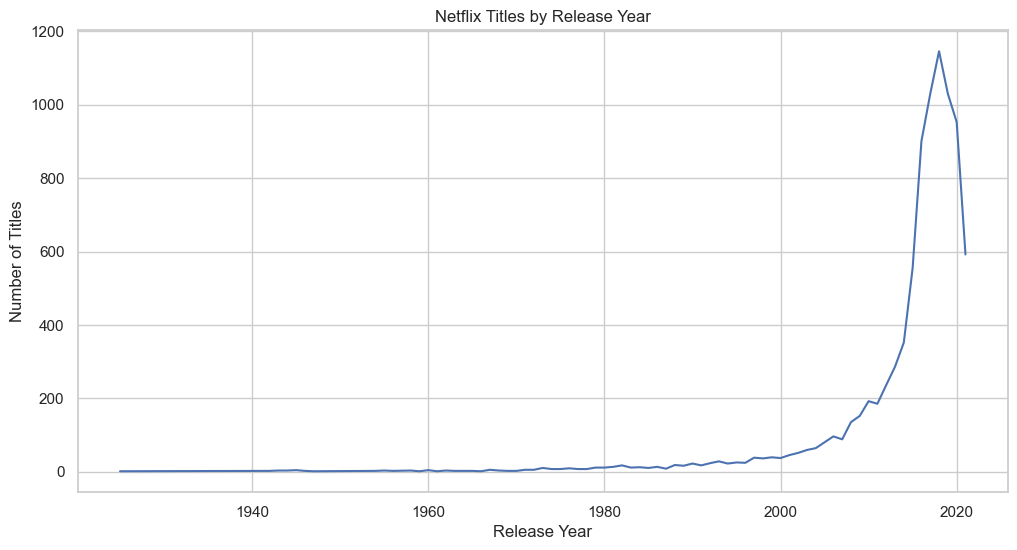

In [21]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=release_year_counts.index,
    y=release_year_counts.values
)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.savefig("../outputs/Netflix_Titles_by_Release_Year.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
type_year = (
    df.groupby(["release_year", "type"])
    .size()
    .reset_index(name="count")
)

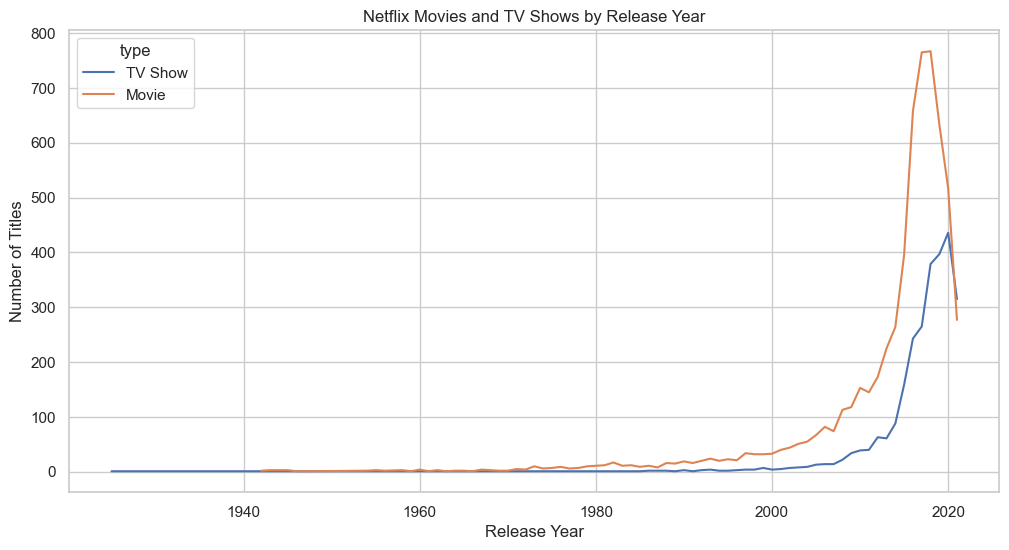

In [23]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=type_year,
    x="release_year",
    y="count",
    hue="type"
)

plt.title("Netflix Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.savefig("../outputs/Netflix_Movies_and_TV_Shows_by_Release_Year.png", dpi=300, bbox_inches="tight")

plt.show()

In [24]:
df = pd.read_csv("../data/netflix_cleaned.csv")
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   show_id         8790 non-null   object
 1   type            8790 non-null   object
 2   title           8790 non-null   object
 3   director        6202 non-null   object
 4   country         8503 non-null   object
 5   date_added      8790 non-null   object
 6   release_year    8790 non-null   int64 
 7   rating          8790 non-null   object
 8   duration        8790 non-null   object
 9   listed_in       8790 non-null   object
 10  added_year      8790 non-null   int64 
 11  added_month     8790 non-null   int64 
 12  duration_value  8790 non-null   int64 
 13  duration_unit   8790 non-null   object
dtypes: int64(4), object(10)
memory usage: 961.5+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8786,9-Feb,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6202,4527,Rajiv Chilaka,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8503,85,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,2020-01-01,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790.0,NaN,NaN,NaN,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8790,14,TV-MA,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
type_counts = df["type"].value_counts()

type_counts

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [26]:
type_percentage = df["type"].value_counts(normalize=True) * 100

type_percentage.round(2)

type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64

In [27]:
content_distribution = pd.DataFrame({
    "Count": type_counts,
    "Percentage": type_percentage.round(2)
})

content_distribution

,Count,Percentage
type,,
Movie,6126,69.69
TV Show,2664,30.31


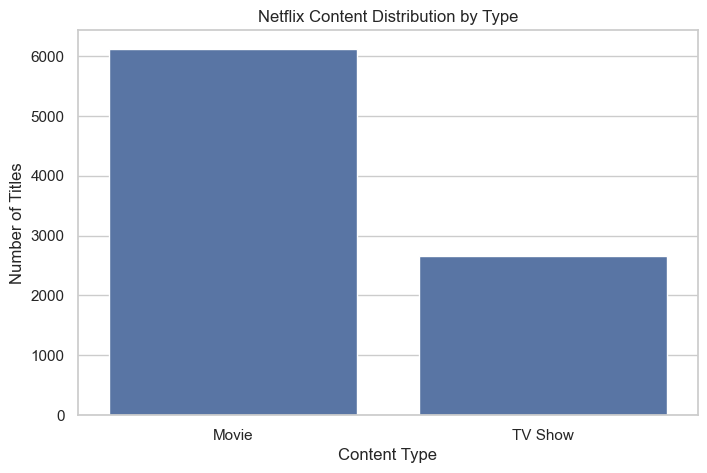

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Netflix Content Distribution by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.savefig("../outputs/Netflix_Content_Distribution_by_Type.png", dpi=300, bbox_inches="tight")

plt.show()

### Finding

Movies dominate the Netflix dataset, accounting for 69.69% of the total titles, while TV Shows represent 30.31%. This indicates that the dataset contains more than twice as many Movies as TV Shows.

## 5. Key Findings

The exploratory data analysis of the Netflix dataset revealed several important patterns and trends:

### 1. Content Distribution
- The dataset contains 8,790 Netflix titles.
- Movies account for 6,126 titles (69.69%).
- TV Shows account for 2,664 titles (30.31%).
- Movies therefore represent the majority of the Netflix catalog in the dataset.

### 2. Popular Content Categories
- International Movies are the most common category with 2,752 titles.
- Dramas are the second most common category with 2,426 titles.
- Comedies rank third with 1,674 titles.
- International TV Shows and Documentaries are also among the major categories.

### 3. Content Ratings
- TV-MA is the most common rating with 3,205 titles.
- TV-14 is the second most common rating with 2,157 titles.
- TV-PG follows with 861 titles.
- This indicates a substantial presence of mature and teen-oriented content in the dataset.

### 4. Release Year Trends
- The release-year analysis shows that the Netflix catalog contains a large proportion of titles from more recent years.
- The trend visualization helps identify periods of increased content production and changes in the catalog over time.

### 5. Overall Insight
The analysis shows that Netflix's catalog in this dataset is strongly dominated by Movies, with International Movies, Dramas, and Comedies among the leading categories. The rating distribution also indicates a significant amount of mature and teen-oriented content.